In [6]:
# Importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [7]:
fandango = pd.read_csv("fandango_scrape.csv")

# Understandig the data

In [8]:
fandango.head()

,FILM,STARS,RATING,VOTES
0,Fifty Shades of Grey (2015),4.0,3.9,34846
1,Jurassic World (2015),4.5,4.5,34390
2,American Sniper (2015),5.0,4.8,34085
3,Furious 7 (2015),5.0,4.8,33538
4,Inside Out (2015),4.5,4.5,15749


In [9]:
fandango.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FILM    504 non-null    str    
 1   STARS   504 non-null    float64
 2   RATING  504 non-null    float64
 3   VOTES   504 non-null    int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 15.9 KB


In [10]:
fandango.describe()

,STARS,RATING,VOTES
count,504.000000,504.000000,504.000000
mean,3.558532,3.375794,1147.863095
std,1.563133,1.491223,3830.583136
min,0.000000,0.000000,0.000000
25%,3.500000,3.100000,3.000000
50%,4.000000,3.800000,18.500000
75%,4.500000,4.300000,189.750000
max,5.000000,5.000000,34846.000000


<Axes: xlabel='RATING', ylabel='VOTES'>

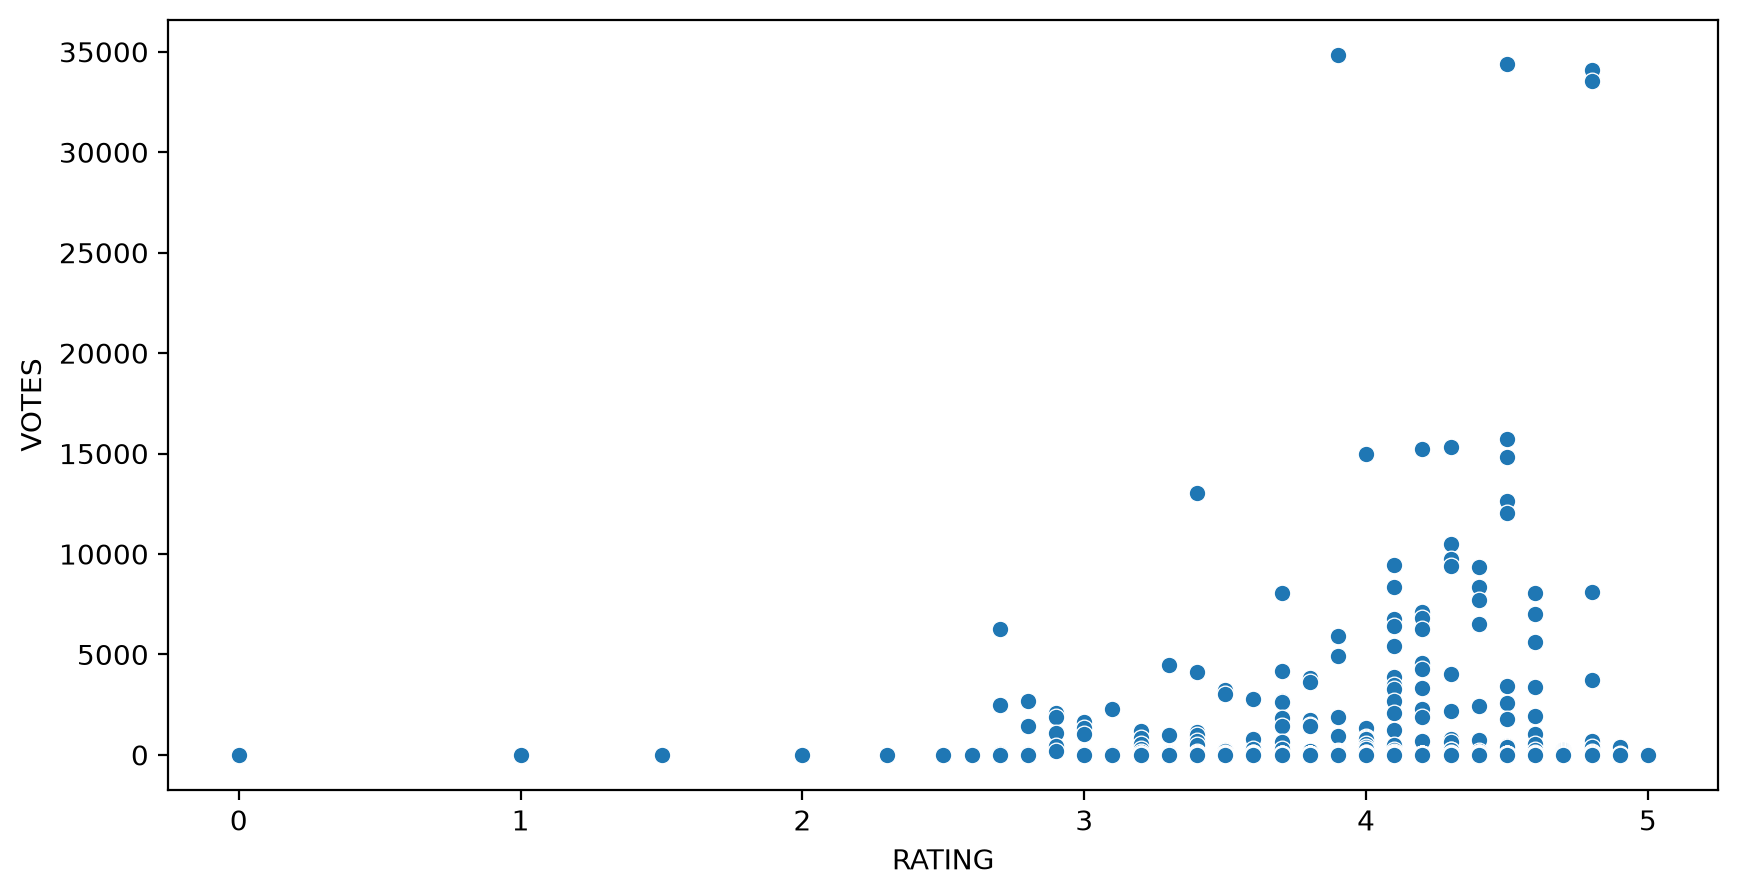

In [11]:
plt.figure(figsize=(10,5), dpi = 200)
sns.scatterplot(data= fandango, x = "RATING", y = "VOTES")

In [12]:
fandango.corr(numeric_only=True)

,STARS,RATING,VOTES
STARS,1.000000,0.994696,0.164218
RATING,0.994696,1.000000,0.163764
VOTES,0.164218,0.163764,1.000000


In [13]:

# Separating the year of the film and setting it to a new column

title = "Film Title Name (Year)"
title.split("(")[-1].replace(")", "")

fandango["YEAR"] = fandango["FILM"].apply(lambda title: title.split("(")[-1].replace(")", ""))
fandango["YEAR"]

0      2015
1      2015
2      2015
3      2015
4      2015
       ... 
499    2015
500    2015
501    2015
502    1964
503    2012
Name: YEAR, Length: 504, dtype: str

In [14]:

fandango.head()

,FILM,STARS,RATING,VOTES,YEAR
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015
1,Jurassic World (2015),4.5,4.5,34390,2015
2,American Sniper (2015),5.0,4.8,34085,2015
3,Furious 7 (2015),5.0,4.8,33538,2015
4,Inside Out (2015),4.5,4.5,15749,2015


In [15]:
# No. of movies per year

fandango.value_counts(subset="YEAR")

YEAR
2015    478
2014     23
2016      1
1964      1
2012      1
Name: count, dtype: int64

<Axes: xlabel='YEAR', ylabel='count'>

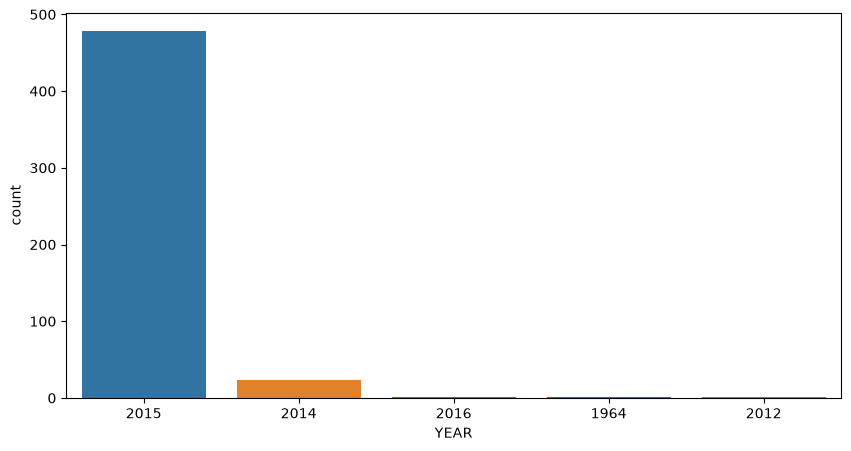

In [16]:
# PLotting count of movies per year

plt.figure(figsize=(10,5))
sns.countplot(data=fandango, x = "YEAR", hue = "YEAR")

In [17]:
# 10 movies with the largest number of votes

fandango.nlargest(10, "VOTES")

,FILM,STARS,RATING,VOTES,YEAR
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015
1,Jurassic World (2015),4.5,4.5,34390,2015
2,American Sniper (2015),5.0,4.8,34085,2015
3,Furious 7 (2015),5.0,4.8,33538,2015
4,Inside Out (2015),4.5,4.5,15749,2015
5,The Hobbit: The Battle of the Five Armies (2014),4.5,4.3,15337,2014
6,Kingsman: The Secret Service (2015),4.5,4.2,15205,2015
7,Minions (2015),4.0,4.0,14998,2015
8,Avengers: Age of Ultron (2015),5.0,4.5,14846,2015
9,Into the Woods (2014),3.5,3.4,13055,2014


In [18]:
# movies with zero votes

(fandango["VOTES"] == 0).sum()

np.int64(69)

In [21]:
# Building a dataframe of only reviewed films by removing any films that have zero votes

fan_reviewd = fandango[fandango["VOTES"]>0]
fan_reviewd

,FILM,STARS,RATING,VOTES,YEAR
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015
1,Jurassic World (2015),4.5,4.5,34390,2015
2,American Sniper (2015),5.0,4.8,34085,2015
3,Furious 7 (2015),5.0,4.8,33538,2015
4,Inside Out (2015),4.5,4.5,15749,2015
...,...,...,...,...,...
430,That Sugar Film (2015),5.0,5.0,1,2015
431,The Intern (2015),5.0,5.0,1,2015
432,The Park Bench (2015),5.0,5.0,1,2015
433,The Wanted 18 (2015),5.0,5.0,1,2015


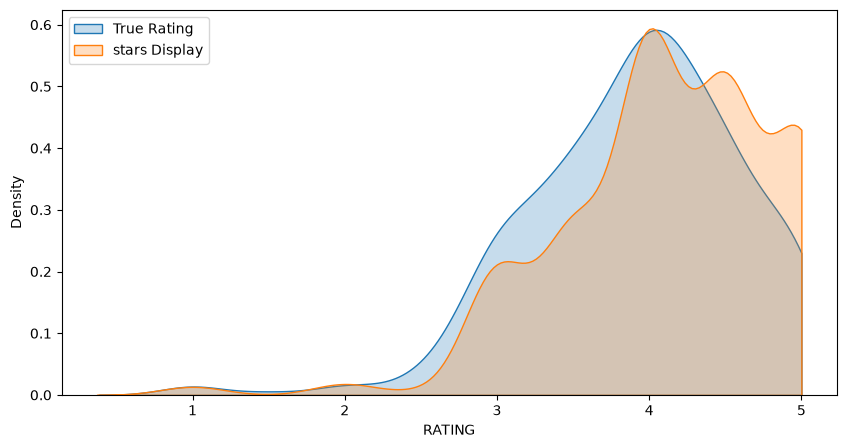

In [28]:
# Creating a KDE plot
plt.figure(figsize=(10,5))
sns.kdeplot(data = fan_reviewd, x = "RATING", clip=[0,5], fill=True, label = "True Rating")
sns.kdeplot(data = fan_reviewd, x = "STARS", clip=[0,5], fill=True, label = "stars Display")

plt.legend()

In [38]:
fan_reviewd["DISCREPANCY"] = fan_reviewd["STARS"] - fan_reviewd["RATING"]
fan_reviewd.head()
fan_reviewd["DISCREPANCY"] = fan_reviewd["DISCREPANCY"].round(2)

<Axes: xlabel='DISCREPANCY', ylabel='count'>

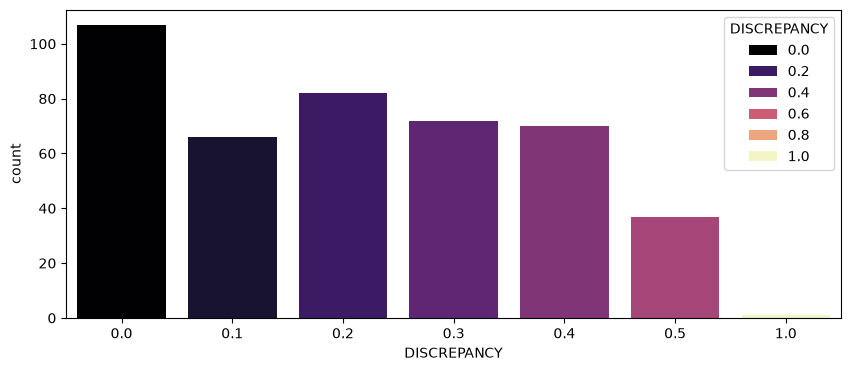

In [40]:
# Creating a count plot displaying the no. of times a certain difference occurs

plt.figure(figsize=(10,4))
sns.countplot(data = fan_reviewd, x="DISCREPANCY", hue = "DISCREPANCY", palette="magma")

In [ ]:
# Movie with 1 star difference

fan_reviewd[fan_reviewd["DISCREPANCY"] == 1]

,FILM,STARS,RATING,VOTES,YEAR,DISCREPANCY
381,Turbo Kid (2015),5.0,4.0,2,2015,1.0
